In [1]:
import pandas as pd, si_units as si, matplotlib.pyplot as plt, numpy as np, PLOT_SETTINGS as ps, matplotlib.ticker as ticker, ast, os
import feos
from molmass import Formula
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.lines import Line2D
from io import StringIO
import ternary

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'

ch4 = Formula("CH4")
n2  = Formula("N2")
co2 = Formula("CO2")
# h2o = Formula("H2O")
# molar_masses = np.array([ch4.mass, n2.mass, co2.mass])

In [2]:
# parameters          = feos.Parameters.from_json(["argon", "nitrogen", "hydrogen"], "parameters.json")
# # kij                 = kij(temperature)
# parameters

In [3]:
z               = np.array([0.25, 0.25, 0.5])  # mole fractions of Argon, Nitrogen, Hydrogen
parameters      = feos.Parameters.from_json(["argon", "nitrogen", "hydrogen"], "parameters.json")
pcsaft_helmz    = feos.HelmholtzEnergyFunctional.pcsaft(parameters)
T               = 100* si.KELVIN
P               = 20e5* si.PASCAL
feed            = z * si.MOL

parameters
# eq_bub = feos.PhaseEquilibrium.bubble_point(pcsaft_helmz, T*si.KELVIN, z)
# eq_bub.vapor

|component|molarweight|m|sigma|epsilon_k|nb|k_ij|l_ij|
|-|-|-|-|-|-|-|-|
|argon|39.962|1.0|3.37751|117.80903||||
|nitrogen|28.006|1.23831|3.30009|89.41358|2.0|||
|hydrogen|2.016|1.0|3.002|51.343||0.0|0.0|

In [4]:
# eos = feos.EquationOfState.pcsaft(parameters)
eos = feos.HelmholtzEnergyFunctional.pcsaft(parameters)
eq  = feos.PhaseEquilibrium.tp_flash(eos, T, P, feed)
liq = eq.liquid
vap = eq.vapor
cp  = feos.State.critical_point(eos, feed/si.MOL, initial_temperature= T)

critical_temperature = cp.temperature
print("Critical Temperature (K): ", critical_temperature/si.KELVIN)

Critical Temperature (K):  112.45740864279072


In [5]:
x_pt = [tuple(liq.molefracs.tolist())]
y_pt = [tuple(vap.molefracs.tolist())]

/home/darshan/A6/py_A6/lib/python3.12/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


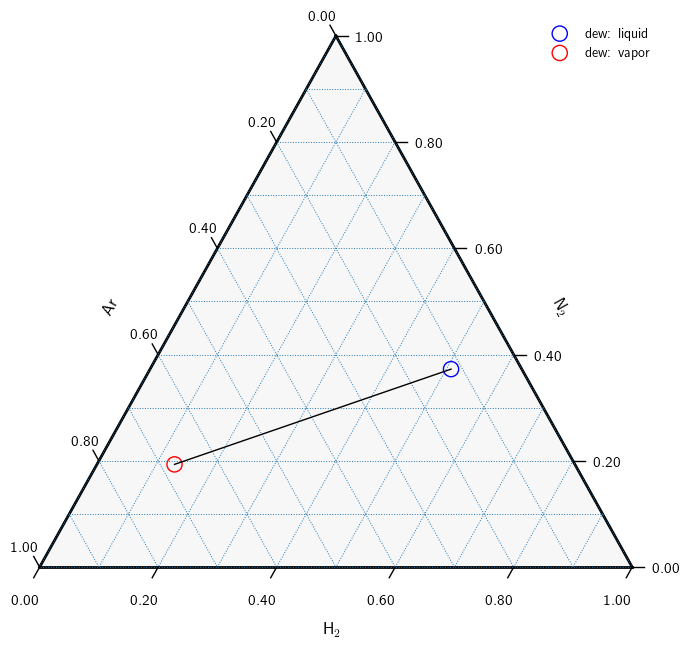

In [6]:
fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(7, 6.5)

tax.boundary(linewidth=2)
tax.gridlines(multiple=0.1, linewidth=0.7)

tax.left_axis_label("Ar", offset=0.14, fontsize=12)
tax.right_axis_label("N$_2$", offset=0.14, fontsize=12)
tax.bottom_axis_label("H$_2$", offset=0.02, fontsize=12)

tax.ticks(axis="lbr",multiple=0.2,linewidth=1,fontsize=11,offset=0.02,tick_formats="%.2f")

tax.scatter(x_pt, marker="o", s=120, facecolors="none", edgecolors="blue", label="dew: liquid")
tax.scatter(y_pt, marker="o", s=120, facecolors="none", edgecolors="red", label="dew: vapor")

# optional tie-line
tax.line(x_pt[0], y_pt[0], linewidth=1, color='k')

tax.get_axes().set_axis_off()
tax.clear_matplotlib_ticks()
tax.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()

In [7]:
interface       = feos.PlanarInterface.from_tanh(vle=eq,n_grid=500, l_grid=100*si.ANGSTROM, critical_temperature=critical_temperature)
surface_tension = interface.solve().surface_tension
surface_tension

4.669810085634774 mN/m